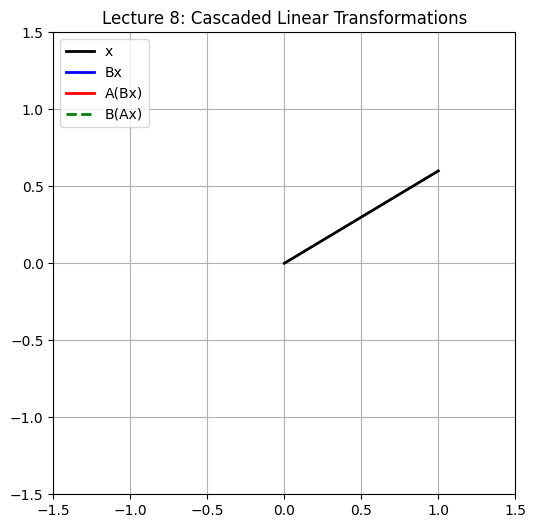

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Define Lecture 8 matrices
# -----------------------------

# B: rotation by 30 degrees
theta = np.deg2rad(30)
B = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

# A: projection onto x-axis
A = np.array([
    [1, 0],
    [0, 0]
])

AB = A @ B     # cascade result
BA = B @ A     # wrong order (for comparison)

# Initial vector
x = np.array([1.0, 0.6])

# Precompute results
Bx = B @ x
ABx = A @ Bx
BAx = B @ A @ x

# -----------------------------
# Animation setup
# -----------------------------

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.grid(True)
ax.set_title("Lecture 8: Cascaded Linear Transformations")

# Vector arrows
v_x, = ax.plot([], [], lw=2, color='black', label='x')
v_Bx, = ax.plot([], [], lw=2, color='blue',  label='Bx')
v_ABx, = ax.plot([], [], lw=2, color='red',   label='A(Bx)')
v_BAx, = ax.plot([], [], lw=2, color='green', linestyle='--', label='B(Ax)')

ax.legend(loc="upper left")

# -----------------------------
# Frame update function
# -----------------------------

def update(frame):
    v_x.set_data([0, x[0]], [0, x[1]])

    if frame >= 20:
        v_Bx.set_data([0, Bx[0]], [0, Bx[1]])
    else:
        v_Bx.set_data([], [])

    if frame >= 40:
        v_ABx.set_data([0, ABx[0]], [0, ABx[1]])
    else:
        v_ABx.set_data([], [])

    if frame >= 60:
        v_BAx.set_data([0, BAx[0]], [0, BAx[1]])
    else:
        v_BAx.set_data([], [])

    return v_x, v_Bx, v_ABx, v_BAx


anim = FuncAnimation(fig, update, frames=80, interval=100)
HTML(anim.to_jshtml())